# <p align = "center"> Conformation Analysis </p>
## <p align = "center"> B-factors </p>


In [89]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM, sele_closest_Chain
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord
from xaidar.data.molecModels import structAlign

# Looking at natural flexibility of Ground-state Active Site



- # B-factors

In [90]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)

# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

# 3. Load Fragalysis Ligand Files
fragScreenLigPath = fragalysisDir / "02-chemofint/fragscreen_lig.sdf"
fragScreenLigs = Chem.SDMolSupplier( str(fragScreenLigPath), removeHs=False)
piperidLigPath = rootProjDir / "02-chemofint/piperidir_lig.sdf"
piperidLigs = Chem.SDMolSupplier( str(piperidLigPath), removeHs=False)


In [91]:
# Calculate mean CoM for all ligands (mean_CoM)
from xaidar.data.molecModels import rdkit_to_gemmi

lst_ligs = [ flatten_pdb( lig_pdb, "residue")[0] for lig_pdb in rdkit_to_gemmi(piperidLigs)]
CoM_array = get_res_CoM(  lst_ligs  )
# print( "Ligands CoM array shape: ", CoM_array.shape)
mean_CoM = CoM_array.mean(axis=0)
mean_CoM = gemmi.Position( *mean_CoM )
print( "Mean CoM from all ligands: ",mean_CoM )

Mean CoM from all ligands:  <gemmi.Position(8.93134, 13.2798, 23.3181)>


In [92]:
# Filter Protein Sequences to only chains closest to the ligands mean CoM -> (lst_prots, prot_logs)
from xaidar.data.protocols import load_and_filter_Proteins

nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

print("\t\t       #Dirs  #AfterFilter")
print( "Nonactive Proteins:\t{}\t{}".format(len(list(nonactivepdbs_dir.iterdir())),
                                             len(nonactive_prots)))
print("FragScreen Proteins:\t{}\t{}".format(len(list(fragscreen_dir.iterdir())),
                                            len(fragscreen_prots)))
print("Piperid Proteins:  \t{}\t{}".format(len(list(piperid_dir.iterdir())),
                                           len(piperid_prots)))


		       #Dirs  #AfterFilter
Nonactive Proteins:	99	99
FragScreen Proteins:	42	42
Piperid Proteins:  	454	454


In [93]:
# Test: Calculate Mean CoM of nonactive proteins

nonactive_mean_CoM = np.mean( [ [*flatten_pdb(prot, "model")[0].calculate_center_of_mass()]
                              for prot in nonactive_prots], axis=0)
print("Nonactive Mean CoM: ", nonactive_mean_CoM )

Nonactive Mean CoM:  [15.0495119   7.02464838 14.95924213]


In [94]:
# Get ligands from proteins based on mean CoM of proteins
from xaidar.data.protocols import extract_lig_from_prot
nonactive_mean_CoM = np.mean( [ [*flatten_pdb(prot, "model")[0].calculate_center_of_mass()]
                              for prot in nonactive_prots], axis=0)
fragscreen_mean_CoM = np.mean( [ [*flatten_pdb(prot, "model")[0].calculate_center_of_mass()]
                              for prot in fragscreen_prots], axis=0)
piperid_mean_CoM = np.mean( [ [*flatten_pdb(prot, "model")[0].calculate_center_of_mass()]
                              for prot in piperid_prots], axis=0)

nonactive_ligs = extract_lig_from_prot( nonactivepdbs_dir, coord = nonactive_mean_CoM )
fragscreen_ligs = extract_lig_from_prot( fragscreen_dir, coord = fragscreen_mean_CoM )
piperid_ligs = extract_lig_from_prot( piperid_dir, coord = piperid_mean_CoM )

print("\t\t       #Dirs  #After Filter")
print("Nonactive Ligs :\t{}\t{}".format(len(list(nonactivepdbs_dir.iterdir())),
                                             len(nonactive_ligs)))
print("FragScreen Ligs:\t{}\t{}".format(len(list(fragscreen_dir.iterdir())),
                                            len(fragscreen_ligs)))
print("Piperid Ligs   :  \t{}\t{}".format(len(list(piperid_dir.iterdir())),
                                           len(piperid_ligs)))


		       #Dirs  #After Filter
Nonactive Ligs :	99	99
FragScreen Ligs:	42	42
Piperid Ligs   :  	454	454


- ## Align proteins and fragments

In [95]:
ref_prot  = gemmi.read_pdb( "../../../../data/ev2a/fragalysis/02-chemofint/fragscreen/A0926a/A0926a.pdb" )
ref_lig = sele_pdb( ref_prot, sele_Lig)
lig_com = get_res_CoM( flatten_pdb( ref_prot, "residue") )
ref_prot = sele_pdb( ref_prot, sele_AA)
ref_prot = sele_pdb( ref_prot, sele_closest_Chain, gemmi.Position(*lig_com[0]) )
get_pdb_stats( ref_prot )


####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.


In [96]:
aligned_data = {}
for name, prots, ligs in zip( ["nonactive", "fragscreen", "piperid"],
                              [nonactive_prots, fragscreen_prots, piperid_prots],
                              [nonactive_ligs, fragscreen_ligs, piperid_ligs] ):
    aligned_molecs = {"prot":[], "lig":[]}
    for prot, lig in zip( prots, ligs):
        align_matrix =  structAlign(ref_prot, prot).calc_transform().transform
        prot_aligned = structAlign(None, prot).apply_transform( transform = align_matrix ).aligned_prot
        lig_aligned = structAlign( None, lig).apply_transform( transform = align_matrix ).aligned_prot
        aligned_molecs["prot"].append( prot_aligned )
        aligned_molecs["lig"].append( lig_aligned )
    aligned_data[name] = aligned_molecs

for name in ["nonactive", "fragscreen", "piperid"]:
    print( "{}: Aligned Proteins: {}, Aligned Ligands: {}".format(
        name, len(aligned_data[name]["prot"]), len(aligned_data[name]["lig"]) ) )


nonactive: Aligned Proteins: 99, Aligned Ligands: 99
fragscreen: Aligned Proteins: 42, Aligned Ligands: 42
piperid: Aligned Proteins: 454, Aligned Ligands: 454


In [97]:
# save aligned proteins and ligands to disk
from xaidar.data.molecModels import savePDB
prot_names = {
    "nonactive": [ dir.name for dir in nonactivepdbs_dir.iterdir() if dir.is_dir() ],
    "fragscreen": [ dir.name for dir in fragscreen_dir.iterdir() if dir.is_dir() ],
    "piperid": [ dir.name for dir in piperid_dir.iterdir() if dir.is_dir() ],
}
# for name in ["nonactive", "fragscreen", "piperid"]:
#     print( "{} Protein Names: {}".format( name, len(prot_names[name]) ) )

Path("tmp").mkdir( exist_ok= True)
for name in ["nonactive", "fragscreen", "piperid"]:
    Path(f"tmp/{name}").mkdir( exist_ok= True)
    for file_type in ["prot", "lig"]:
        for prot_name, prot, lig in zip(prot_names[name],
                                        aligned_data[name]["prot"],
                                        aligned_data[name]["lig"] ):
            savePDB(prot, Path("tmp")/name/(prot_name + "_prot_aligned.pdb") )
            savePDB(lig, Path("tmp")/name/(prot_name + "_lig_aligned.pdb") )


- ## Filter Out Ligands in Nonactive that are too close to the active site

In [98]:
active_site_ligs = [ name for name in prot_names["piperid"] if name != "A4596b" ]

active_site_CoM = np.mean( [ get_res_CoM( flatten_pdb(aligned_data["piperid"]["lig"][ prot_names["piperid"].index(name) ], "residue") )
                            for name in active_site_ligs ], axis=0)[0]
print("Active Site CoM: ", active_site_CoM )

Active Site CoM:  [ 29.74732168 -16.03482984   7.31012728]


In [99]:
prot_names = {
    "nonactive": [ dir.name for dir in nonactivepdbs_dir.iterdir() if dir.is_dir() ],
    "fragscreen": [ dir.name for dir in fragscreen_dir.iterdir() if dir.is_dir() ],
    "piperid": [ dir.name for dir in piperid_dir.iterdir() if dir.is_dir() ],
}
nonactive_ligs_names = []
active_ligs_names = []
for lig, name in zip(aligned_data["nonactive"]["lig"],
                     prot_names["nonactive"] ):
    lig_CoM = get_res_CoM( flatten_pdb(lig, "residue") )[0]
    dist = np.linalg.norm( lig_CoM - active_site_CoM )
    # print("Ligand CoM: ", lig_CoM, " Distance to Active Site CoM: ", dist )
    if dist < 2.0:
        active_ligs_names.append( name )
    elif dist >= 20.0:
        nonactive_ligs_names.append( name )
print("Active Ligand Names: ", len(active_ligs_names))

Active Ligand Names:  24


In [100]:
root_tmp_dir = Path("tmp/nonactive_filtered")
root_tmp_dir.mkdir( exist_ok= True)
root_tmp_dir.joinpath("nonactive").mkdir( exist_ok= True)
root_tmp_dir.joinpath("active").mkdir( exist_ok= True)

for name in ["nonactive", "fragscreen", "piperid"]:
    Path(f"tmp/{name}").mkdir( exist_ok= True)
for file_type in ["prot", "lig"]:
    for prot_name, prot, lig in zip(prot_names["nonactive"],
                                    aligned_data["nonactive"]["prot"],
                                    aligned_data["nonactive"]["lig"] ):
        
        if prot_name in active_ligs_names:
            savePDB(prot, root_tmp_dir/"active"/(prot_name + "_prot_aligned.pdb") )
            savePDB(lig, root_tmp_dir/"active"/(prot_name + "_lig_aligned.pdb") )
        elif prot_name in nonactive_ligs_names:
            savePDB(prot, root_tmp_dir/"nonactive"/(prot_name + "_prot_aligned.pdb") )
            savePDB(lig, root_tmp_dir/"nonactive"/(prot_name + "_lig_aligned.pdb") )

- ## Analyse Real nonactive proteins b-factors

In [26]:
real_nonactive_prots = []
prot_dir = Path("tmp/nonactive_filtered/nonactive")
for prot_name in prot_dir.glob("*prot*.pdb"):
    real_nonactive_prots.append( gemmi.read_pdb( str(prot_name) ) )

In [27]:
# # Get Query AAs against Ref AAs 
from xaidar.data.molecModels import  get_aa_distribution
nonactive_aa_distrib_dict = get_aa_distribution( ref_prot, real_nonactive_prots, )
print( len(nonactive_aa_distrib_dict) )
print( nonactive_aa_distrib_dict.keys())

140
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139])


In [28]:
# Calculate b-factors for all residue sequences in nonactive_aa_distrib_dict
from xaidar.data.molecModels import get_res_bfactors

aa_distrib_lst = [ nonactive_aa_distrib_dict ]
prot_names = ["Nonactive" ]

res_seqs = list( zip( *nonactive_aa_distrib_dict.values()) ) # nonactive_aa_distrib_dict
all_seqs_bfactors = []
for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                        for seq_bfactors in all_seqs_bfactors ]


print()


print( "\nNumber of residue sequences: ", len(nonactive_aa_distrib_dict))
print( "Number of residues per sequence: ", len(nonactive_aa_distrib_dict[0]) )
print( "First 10 residue b-factors: ", nonactive_aa_distrib_dict[0][:10])



Number of residue sequences:  140
Number of residues per sequence:  39
First 10 residue b-factors:  [<gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>]


In [29]:
bfactor_values = np.array( all_seqs_bfactors )
print( bfactor_values.shape)
nonact_bfactor_mean = np.nanmean( bfactor_values, axis=0)
nonact_bfactor_std = np.nanstd( bfactor_values, axis=0)



(39, 140)


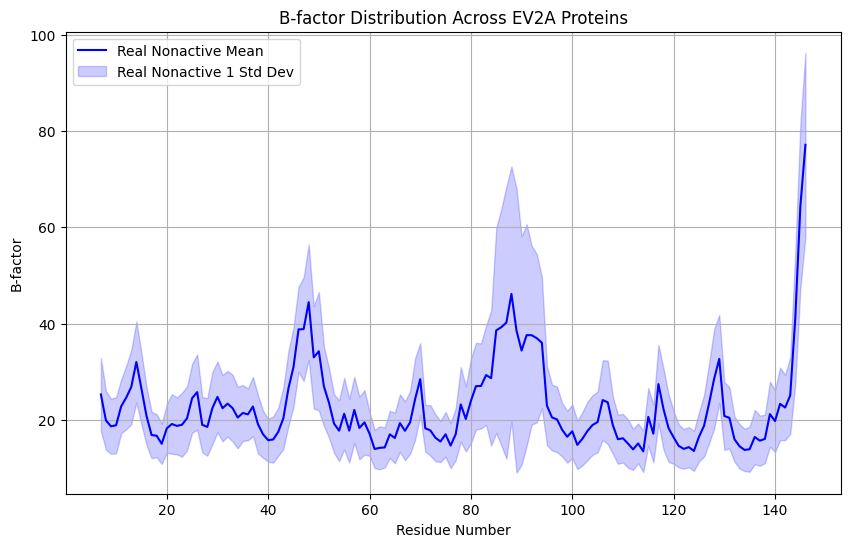

In [17]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, 140+7)
plt.figure(figsize=(10,6))


plt.plot( residues_num, nonact_bfactor_mean, label="{} Mean".format("Real Nonactive")
         , color= "blue")
plt.fill_between( residues_num, nonact_bfactor_mean - nonact_bfactor_std,
                  nonact_bfactor_mean + nonact_bfactor_std, color="blue", alpha=0.2,
                label="{} 1 Std Dev".format("Real Nonactive") )
plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

- # Analysie actual active real

In [22]:
real_nonactive_prots = []
prot_dir = Path("tmp/nonactive_filtered/active")
for prot_name in prot_dir.glob("*prot*.pdb"):
    real_nonactive_prots.append( gemmi.read_pdb( str(prot_name) ) )

In [23]:
# Get Query AAs against Ref AAs 
from xaidar.data.molecModels import  get_aa_distribution
nonactive_aa_distrib_dict = get_aa_distribution( ref_prot, real_nonactive_prots, )
print( len(nonactive_aa_distrib_dict) )
print( nonactive_aa_distrib_dict.keys())

140
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139])


In [24]:
# Calculate b-factors for all residue sequences in nonactive_aa_distrib_dict
from xaidar.data.molecModels import get_res_bfactors

aa_distrib_lst = [ nonactive_aa_distrib_dict ]
prot_names = ["Nonactive" ]

res_seqs = list( zip( *nonactive_aa_distrib_dict.values()) ) # nonactive_aa_distrib_dict
all_seqs_bfactors = []
for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                        for seq_bfactors in all_seqs_bfactors ]


print()


print( "\nNumber of residue sequences: ", len(nonactive_aa_distrib_dict))
print( "Number of residues per sequence: ", len(nonactive_aa_distrib_dict[0]) )
print( "First 10 residue b-factors: ", nonactive_aa_distrib_dict[0][:10])



Number of residue sequences:  140
Number of residues per sequence:  24
First 10 residue b-factors:  [<gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 1(SER) with 6 atoms>, <gemmi.Residue 1(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 1(SER) with 6 atoms>, <gemmi.Residue 1(SER) with 6 atoms>, <gemmi.Residue 7(SER) with 6 atoms>]


In [25]:
bfactor_values = np.array( all_seqs_bfactors )
print( bfactor_values.shape)
act_bfactor_mean = np.nanmean( bfactor_values, axis=0)
act_bfactor_std = np.nanstd( bfactor_values, axis=0)



(24, 140)


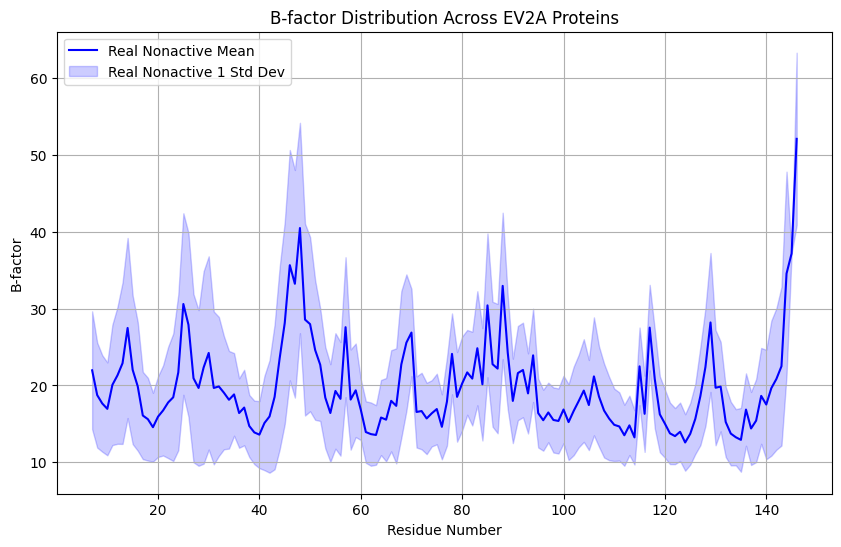

In [22]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, 140+7)
plt.figure(figsize=(10,6))


plt.plot( residues_num, act_bfactor_mean, label="{} Mean".format("Real Nonactive")
         , color= "blue")
plt.fill_between( residues_num, act_bfactor_mean - act_bfactor_std,
                  act_bfactor_mean + act_bfactor_std, color="blue", alpha=0.2,
                label="{} 1 Std Dev".format("Real Nonactive") )
plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

## Plot both

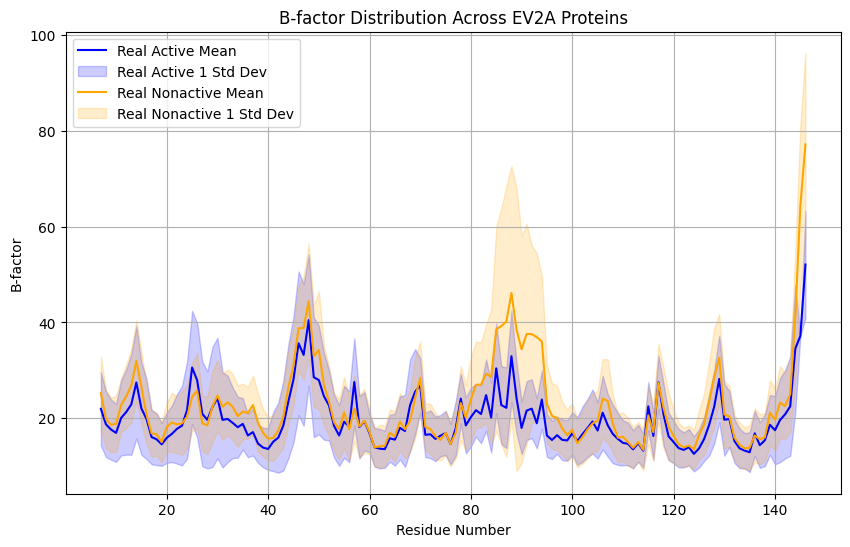

In [23]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, 140+7)
plt.figure(figsize=(10,6))


plt.plot( residues_num, act_bfactor_mean, label="{} Mean".format("Real Active")
         , color= "blue")
plt.fill_between( residues_num, act_bfactor_mean - act_bfactor_std,
                  act_bfactor_mean + act_bfactor_std, color="blue", alpha=0.2,
                label="{} 1 Std Dev".format("Real Active") )
plt.plot( residues_num, nonact_bfactor_mean, label="{} Mean".format("Real Nonactive")
         , color= "orange")
plt.fill_between( residues_num, nonact_bfactor_mean - nonact_bfactor_std,
                  nonact_bfactor_mean + nonact_bfactor_std, color="orange", alpha=0.2,
                label="{} 1 Std Dev".format("Real Nonactive") )

plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

- ## Looking at Piperidine

In [37]:
def plot_bfactors(ref_prot, prots, label):
    from xaidar.data.molecModels import get_aa_distribution, get_res_bfactors
    aa_distrib = get_aa_distribution( ref_prot, prots, )

    res_seqs = list( zip( *aa_distrib.values()) ) # nonactive_aa_distrib_dict
    all_seqs_bfactors = []
    for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
    all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                            for seq_bfactors in all_seqs_bfactors ]
    pip_bfactor_values = np.array( all_seqs_bfactors )
    print( "B-factor values shape: ", pip_bfactor_values.shape)
    pip_bfactor_mean = np.nanmean( pip_bfactor_values, axis=0)
    pip_bfactor_std = np.nanstd( pip_bfactor_values, axis=0)

    import matplotlib.pyplot as plt
    residues_num = np.arange(7, 140+7)
    plt.figure(figsize=(10,6))


    plt.plot( residues_num, pip_bfactor_mean, label="{} Mean".format(label)
            , color= "blue")
    plt.fill_between( residues_num, pip_bfactor_mean - pip_bfactor_std,
                    pip_bfactor_mean + pip_bfactor_std, color="blue", alpha=0.2,
                    label="{} 1 Std Dev".format(label) )
    plt.plot( residues_num, nonact_bfactor_mean, label="{} Mean".format("Real Nonactive")
            , color= "orange")
    plt.fill_between( residues_num, nonact_bfactor_mean - nonact_bfactor_std,
                    nonact_bfactor_mean + nonact_bfactor_std, color="orange", alpha=0.2,
                    label="{} 1 Std Dev".format("Real Nonactive") )

    plt.xlabel("Residue Number")
    plt.ylabel("B-factor")
    plt.title("B-factor Distribution Across EV2A Proteins")
    plt.legend()
    plt.grid()
plt.show()

In [38]:
import re
from pathlib import Path
import gemmi
pip_prots = {"names":[], "prots": []}
pip_ligs = {"names":[], "ligs": []}
prot_dir = Path("tmp/piperid")
for prot_name in prot_dir.glob("*prot*.pdb"):
    pip_prots["prots"].append( gemmi.read_pdb( str(prot_name) ) )
    pip_prots["names"].append( re.search( ".*_prot", prot_name.name).group()[:-5] )
for lig_name in prot_dir.glob("*lig_*.pdb"):
    pip_ligs["ligs"].append( gemmi.read_pdb( str(lig_name) ) )
    pip_ligs["names"].append( re.search( ".*_lig_", lig_name.name).group()[:-5] )

In [39]:
from xaidar.data.molecModels import sele_AA, sele_Lig, sele_closest_Chain
ref_prot  = gemmi.read_pdb( "../../../../data/ev2a/fragalysis/02-chemofint/fragscreen/A0926a/A0926a.pdb" )
ref_lig = sele_pdb( ref_prot, sele_Lig)
lig_com = get_res_CoM( flatten_pdb( ref_prot, "residue") )
ref_prot = sele_pdb( ref_prot, sele_AA)
ref_prot = sele_pdb( ref_prot, sele_closest_Chain, gemmi.Position(*lig_com[0]) )
get_pdb_stats( ref_prot )


####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.


B-factor values shape:  (454, 140)


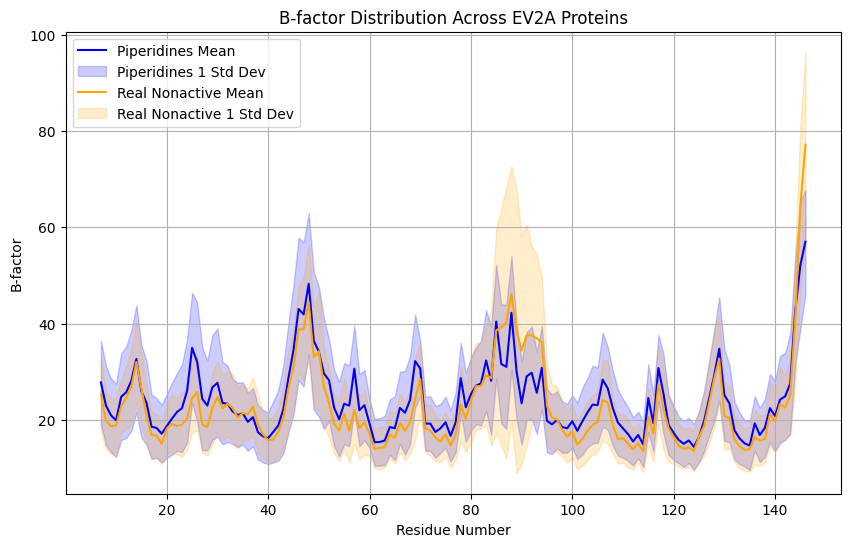

In [40]:
plot_bfactors( ref_prot, pip_prots["prots"], label="Piperidines" )

34
['A5594b', 'A4321a', 'A4654a', 'A4735a', 'A4403a', 'A5884a', 'A5317a', 'A5594a', 'A4812a', 'A3575a', 'A4836a', 'A4283b', 'A5255a', 'A4388a', 'A4748a', 'A3940a', 'A5288a', 'A5879a', 'A5370b', 'A4274a', 'A4753a', 'A4547a', 'A5073a', 'A3884a', 'A4467a', 'A5039b', 'A4350a', 'A4974a', 'A4445b', 'A4431a', 'A4979a', 'A4344a', 'A4712a', 'A5081b']
B-factor values shape:  (34, 140)


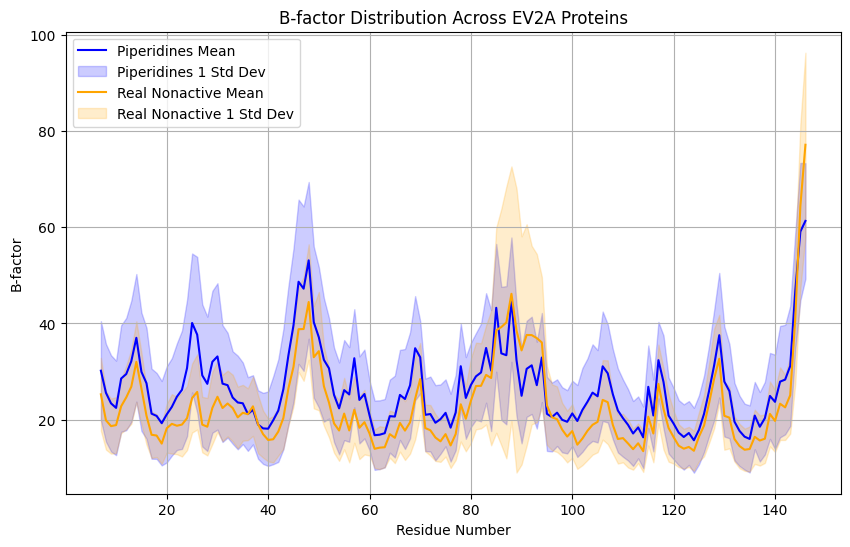

In [104]:
filtered_name = [ idx for idx, prot in enumerate( pip_ligs["ligs"])
                         if len( flatten_pdb(prot, "residue")[0]) >  25]
filter_pip_prots = [ pip_prots["prots"][idx] for idx in filtered_name ]
filtered_prot_name = [ pip_prots["names"][idx]   for idx in filtered_name  ] 
print( len(filter_pip_prots))
print(filtered_prot_name)


plot_bfactors( ref_prot, filter_pip_prots, label="Piperidines" )

29
B-factor values shape:  (29, 140)


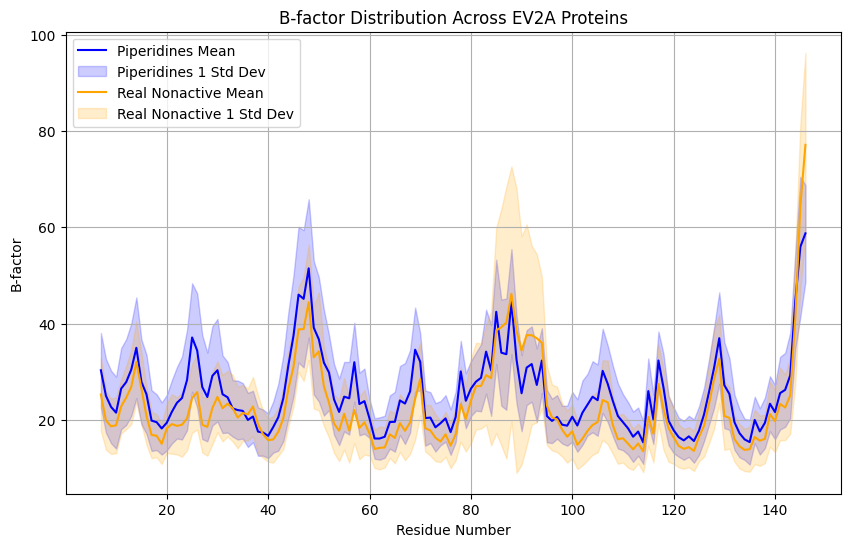

In [54]:
filtered_name = [ idx for idx, prot in enumerate( pip_ligs["ligs"])
                         if len( flatten_pdb(prot, "residue")[0]) <  19]
filter_pip_prots = [ pip_prots["prots"][idx] for idx in filtered_name ]
print( len(filter_pip_prots))

plot_bfactors( ref_prot, filter_pip_prots, label="Piperidines" )

In [55]:
from xaidar.data.molecModels import get_aa_distribution, get_res_bfactors
aa_distrib = get_aa_distribution( ref_prot, pip_prots["prots"], )

res_seqs = list( zip( *aa_distrib.values()) ) # nonactive_aa_distrib_dict
all_seqs_bfactors = []
for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                        for seq_bfactors in all_seqs_bfactors ]
pip_bfactor_values = np.array( all_seqs_bfactors )
print( "B-factor values shape: ", pip_bfactor_values.shape)
pip_bfactor_mean = np.nanmean( pip_bfactor_values, axis=0)
pip_bfactor_std = np.nanstd( pip_bfactor_values, axis=0)

B-factor values shape:  (454, 140)


In [84]:
# 83:93 -> 76 : 86
pip_bfactor_mean = np.round( pip_bfactor_mean, 5)
print(pip_bfactor_mean[76:86] )#-> 78, 79, 80, 81 
values = [40.41796, 31.58032, 30.99757, 42.22692]
res_of_int_idx = []
for val in values: 
    res_of_int_idx.append(np.where(pip_bfactor_mean == val)[0][0])

[32.32544 28.09676 40.41796 31.58032 30.99757 42.22692 30.13839 23.42013
 29.03179 29.76773]


In [ ]:
res_lst = flatten_pdb( ref_prot, "residue" )
res_of_int = [ res_lst[idx] for idx in res_of_int_idx ]
print("Residues of Interest: ", [res.name for res in res_of_int] )
print("Residues of Interest: ", [res.seqid.num for res in res_of_int] )

[<gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 8(GLY) with 4 atoms>, <gemmi.Residue 9(ALA) with 5 atoms>, <gemmi.Residue 10(ILE) with 8 atoms>, <gemmi.Residue 11(TYR) with 12 atoms>, <gemmi.Residue 12(VAL) with 7 atoms>, <gemmi.Residue 13(GLY) with 4 atoms>, <gemmi.Residue 14(ASN) with 8 atoms>, <gemmi.Residue 15(TYR) with 12 atoms>, <gemmi.Residue 16(ARG) with 11 atoms>, <gemmi.Residue 17(VAL) with 7 atoms>, <gemmi.Residue 18(VAL) with 7 atoms>, <gemmi.Residue 19(ASN) with 8 atoms>, <gemmi.Residue 20(ARG) with 11 atoms>, <gemmi.Residue 21(HIS) with 10 atoms>, <gemmi.Residue 22(LEU) with 8 atoms>, <gemmi.Residue 23(ALA) with 5 atoms>, <gemmi.Residue 24(THR) with 7 atoms>, <gemmi.Residue 25(HIS) with 10 atoms>, <gemmi.Residue 26(ASN) with 8 atoms>, <gemmi.Residue 27(ASP) with 8 atoms>, <gemmi.Residue 28(TRP) with 14 atoms>, <gemmi.Residue 29(ALA) with 5 atoms>, <gemmi.Residue 30(ASN) with 8 atoms>, <gemmi.Residue 31(LEU) with 8 atoms>, <gemmi.Residue 32(VAL) with 7 atoms>, <gemmi.